<IPython.core.display.Javascript object>


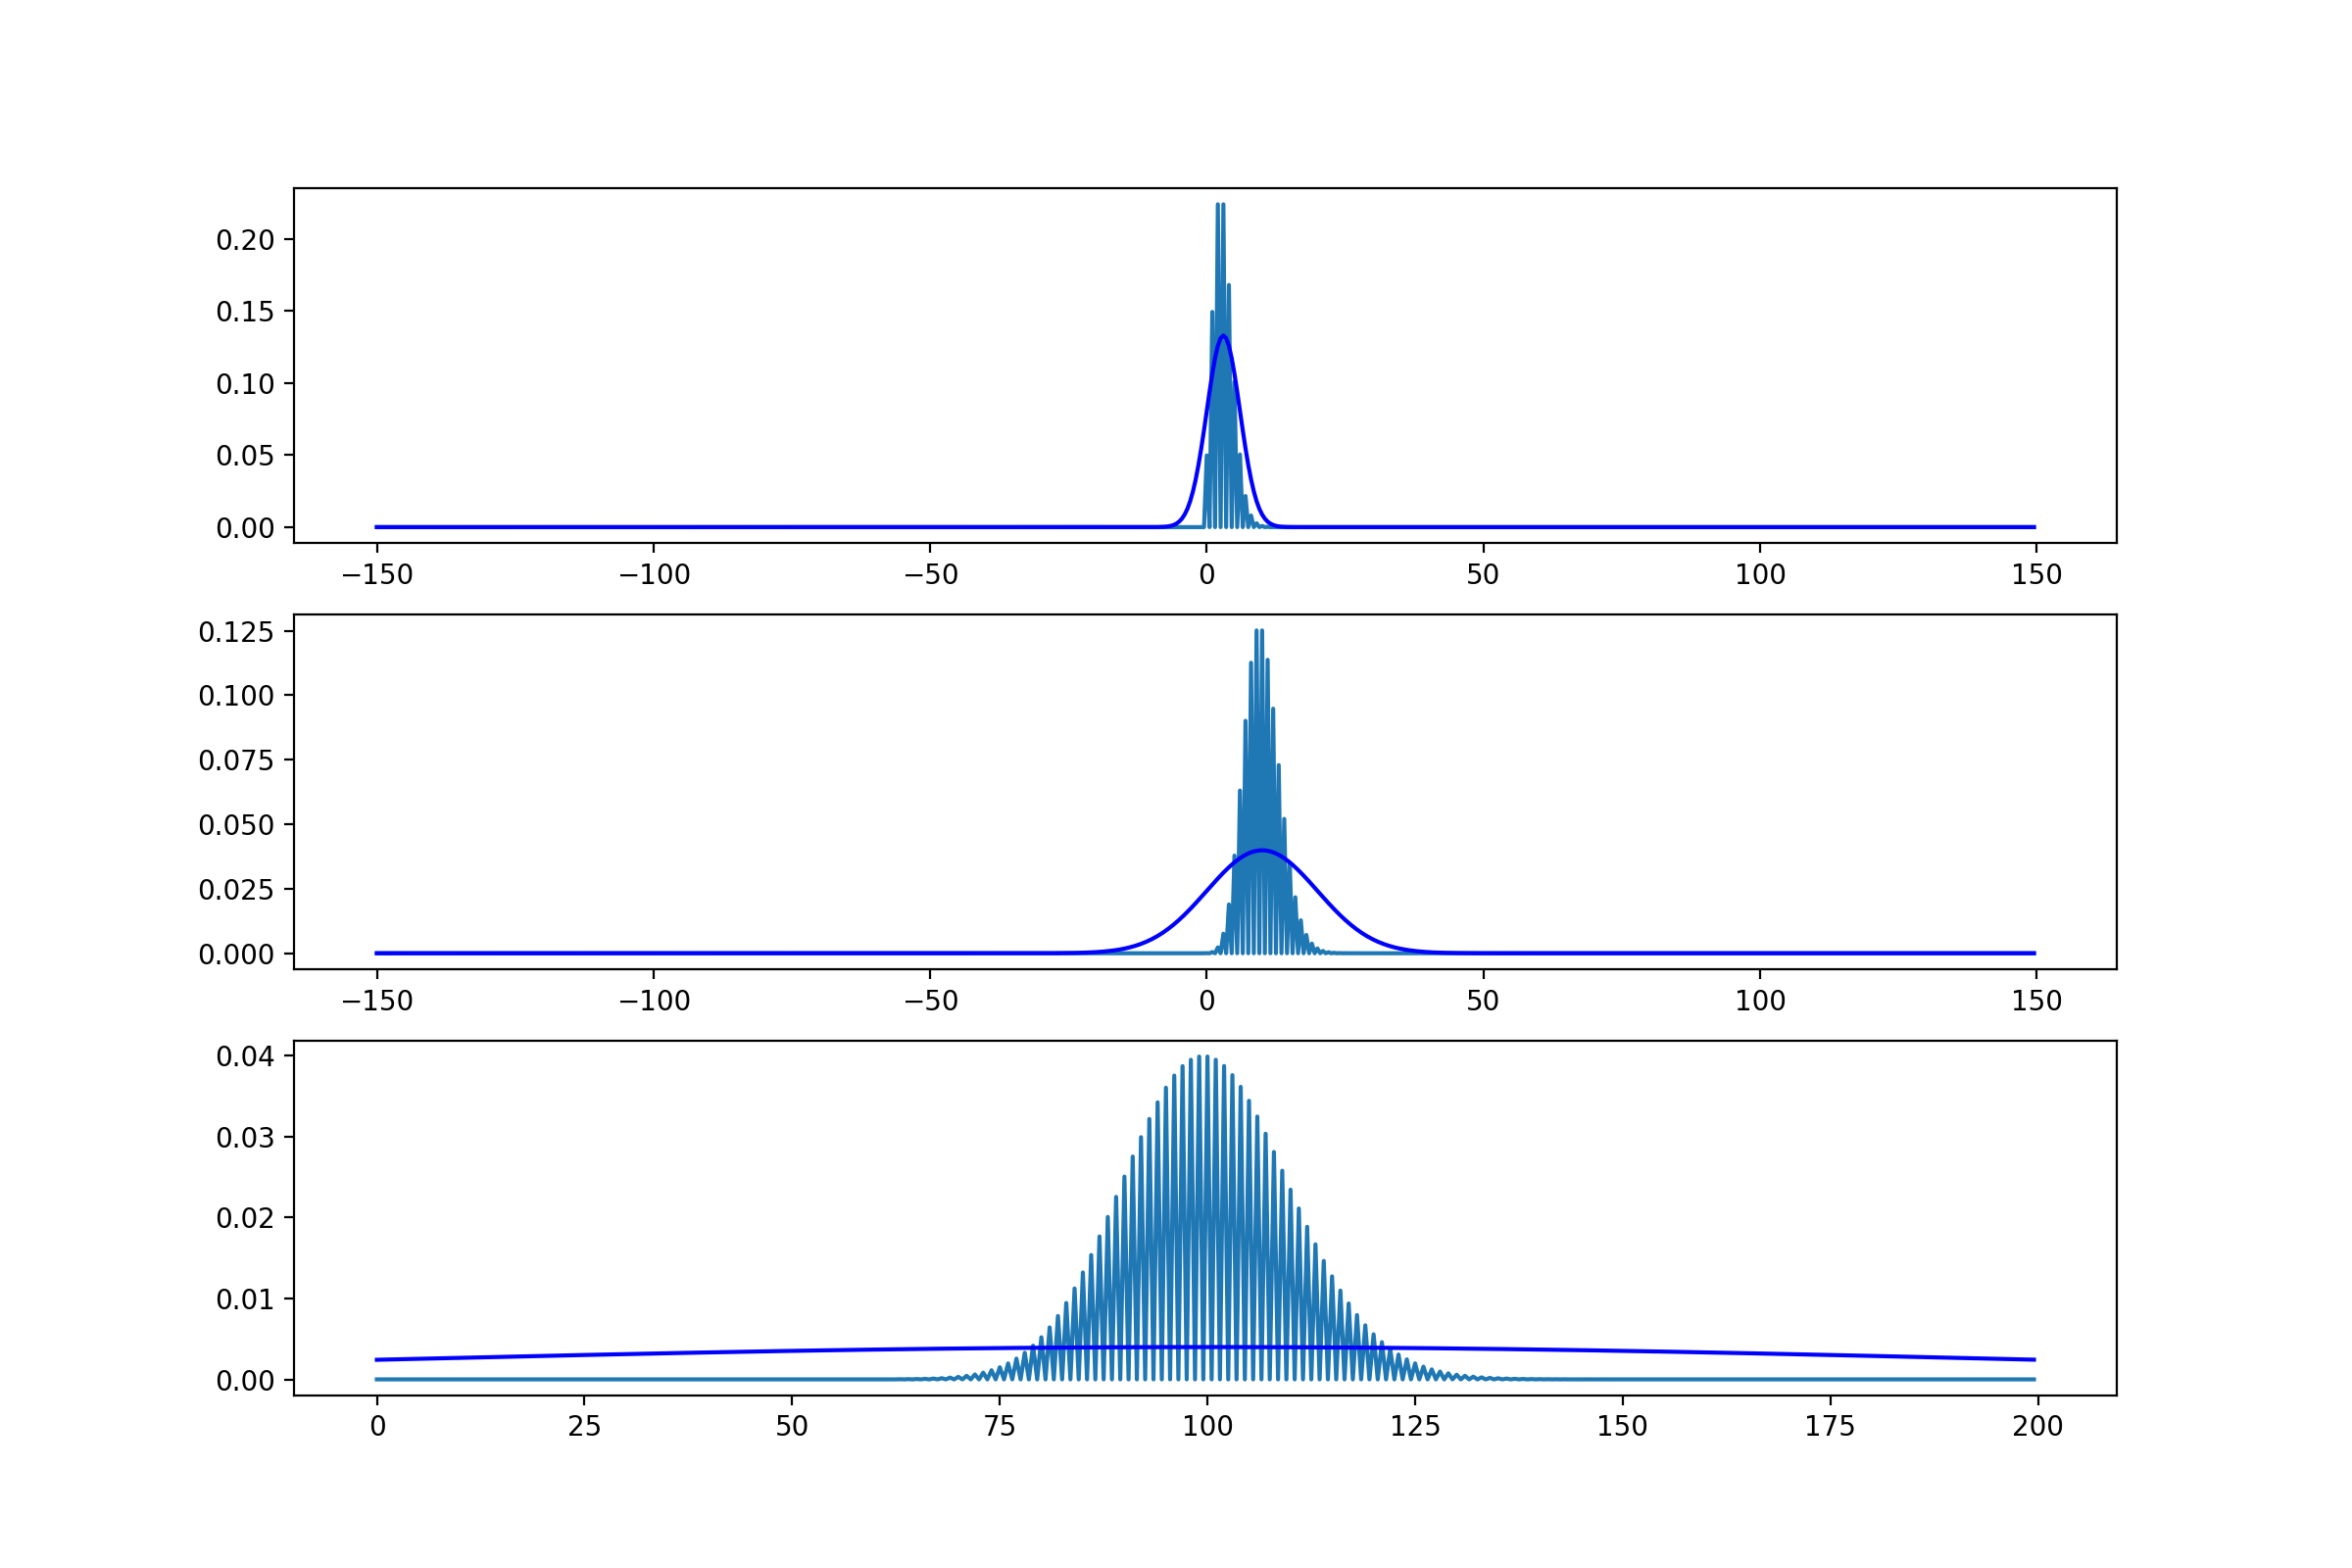

0.22404180765538775
0.12511003572113372
0.039685713804213145
0.09106104752157684
0.08521580768099045
0.0358715740051345


In [42]:
## Problem 2

import numpy as np
from scipy.stats import poisson
from scipy.stats import norm
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,1,figsize = (12,8))
x = np.arange(-150, 150, 0.5)
x1 = np.arange(0, 200, 0.5)

# poisson distribution data for y-axis
a = poisson.pmf(x, mu = 3)
b = poisson.pmf(x, mu = 10)
c = poisson.pmf(x1, mu = 100)

# plotting the graph
ax[0].plot(x, a)
ax[1].plot(x, b)
ax[2].plot(x1, c)

ax[0].plot(x, norm.pdf(x, 3, 3),'b-') 
ax[1].plot(x, norm.pdf(x, 10, 10,),'b-') 
ax[2].plot(x1, norm.pdf(x1, 100, 100),'b-')
# showing the graph
plt.show()

## Part B

## Largest Difference
print(max(poisson.pmf(x1, mu = 3))   - min(norm.pdf(x, 3, 3)) )
print(max(poisson.pmf(x1, mu = 10))  - min(norm.pdf(x, 10, 10)) )
print(max(poisson.pmf(x1, mu = 100)) - min(norm.pdf(x, 100, 100)) )
## Differences between their maxes
print(max(poisson.pmf(x1, mu = 3))   - max(norm.pdf(x, 3, 3)) )
print(max(poisson.pmf(x1, mu = 10))  - max(norm.pdf(x, 10, 10)) )
print(max(poisson.pmf(x1, mu = 100)) - max(norm.pdf(x, 100, 100)) )

In [2]:
#(B) Write a numerical code to compute the same covariance: write function cov(n) that
#1. sets a sample t of random variable T of size n;

import matplotlib.pyplot as plt
import numpy as np
import math
# Part 1
def smple_t(n):
    rng = np.random.default_rng()
    lst = []
    for i in range(0,n):
        x = rng.random()
        lst.append(x)
    return lst
#2. computes x=t**0.5 and y=t**2;
def function(n):
    lst1 = smple_t(n)
    x = [x ** 0.5 for x in lst1]
    y = [y ** 2 for y in lst1]
    
    return x,y

#3. returns the covariance between x and y.
def cov(n):
    x_lst, y_lst = function(n)
    x_sum = 0
    y_sum = 0
    for i in range(0 , len(x_lst) - 1):
        x_sum = x_sum + x_lst[i]
        y_sum = y_sum + y_lst[i]
    x_sample_mean = x_sum / len(x_lst)
    y_sample_mean = y_sum / len(y_lst)
    
    xy_cov = 0
    
    for i in range(0 , len(x_lst) - 1):
        x_dif = x_lst[i] - x_sample_mean
        y_dif = y_lst[i] - y_sample_mean
        xy_cov = xy_cov + x_dif * y_dif
    covariance = xy_cov / (n - 1)
    return covariance
#Print the result of running cov(n) with n = 1000, 10,000, ... and check numerical convergence
print(cov(1000))
print(cov(10000))
print(cov(100000))

#(C) Repeat part (B) with X = exp(T) and Y = log(T), for which analytical results are much
#harder to get and report the covariance with 3 significant digits.
def c_function(n):
    lst1 = smple_t(n)
    x = [math.exp(x) for x in lst1]
    y = [math.log(y) for y in lst1]
    return x,y
def c_cov(n):
    x_lst, y_lst = c_function(n)
    x_sum = 0
    y_sum = 0
    for i in range(0 , len(x_lst) - 1):
        x_sum = x_sum + x_lst[i]
        y_sum = y_sum + y_lst[i]
    x_sample_mean = x_sum / len(x_lst)
    y_sample_mean = y_sum / len(y_lst)
    
    xy_cov = 0
    
    for i in range(0 , len(x_lst) - 1):
        x_dif = x_lst[i] - x_sample_mean
        y_dif = y_lst[i] - y_sample_mean
        xy_cov = xy_cov + x_dif * y_dif
    covariance = xy_cov / (n - 1)
    return covariance
print(c_cov(1000))
print(c_cov(10000))
print(c_cov(100000))

0.06721638480556276
0.06345336155167666
0.06375281548806429
0.391264388428405
0.39829920876256847
0.3997677704248807


<IPython.core.display.Javascript object>


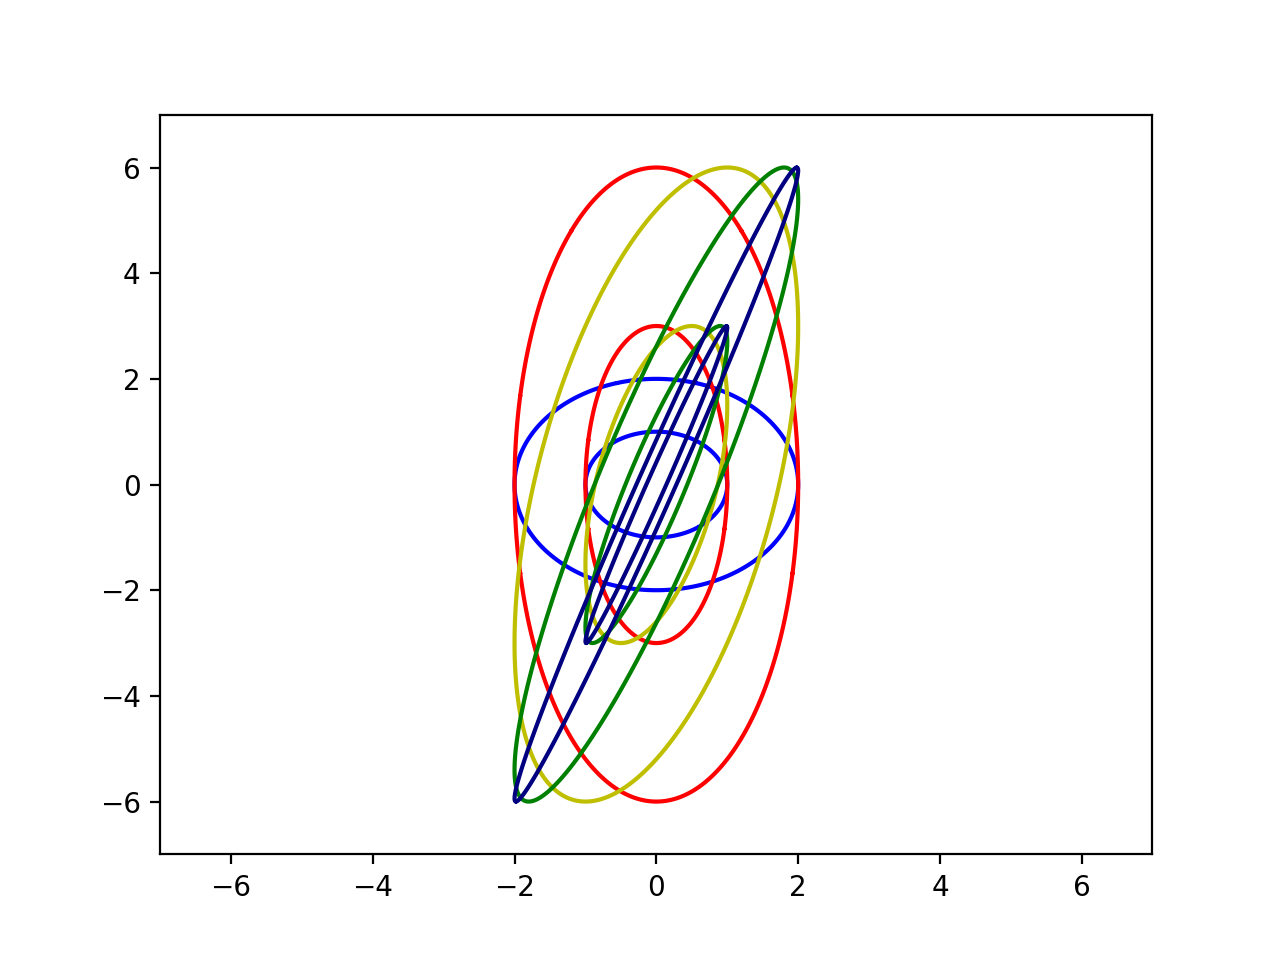

In [41]:
#Problem 4

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import math
%matplotlib notebook

x, y = np.mgrid[-7:7:.01, -7:7:.01]
pos = np.dstack((x, y))
fig = plt.figure()
ax = fig.add_subplot(111)
V1 = math.exp(-2)
V2 = math.exp(-1/2)

# (a,r) = (1,0)
rv = multivariate_normal([0, 0], [[1, 0], [0, 1]])
ax.contour(x, y, rv.pdf(pos),levels = [V1 / (2 * np.pi), V2 / (2 * np.pi)], colors="b")
# 1-sigma confidence intervals x:[-1,1], y:[-1,1]
# 2-sigma confidence intervals x:[-2,2], y:[-2,2]

# (a,r) = (3,0)
rv2 = multivariate_normal([0, 0], [[1, 0], [0, 9]],)
ax.contour(x, y, rv2.pdf(pos),levels = [V1 / (6 * np.pi), V2 / (6 * np.pi)], colors="r")
# 1-sigma confidence intervals x:[-1,1], y:[-3,3]
# 2-sigma confidence intervals x:[-2,2], y:[-6,6]

# (a,r) = (3,0.5)
rv3 = multivariate_normal([0, 0], [[1, 1.5], [1.5, 9]],)
ax.contour(x, y, rv3.pdf(pos),levels = [V1 / (3 * np.pi * np.sqrt(3)), V2 / (3 * np.pi * np.sqrt(3))], colors="y")
# 1-sigma confidence intervals x:[-1,1], y:[-3,3]
# 2-sigma confidence intervals x:[-2,2], y:[-6,6]

# (a,r) = (3,0.9)
rv4 = multivariate_normal([0, 0], [[1, 2.7], [2.7, 9]],)
ax.contour(x, y, rv4.pdf(pos),levels = [5 * V1 / (np.sqrt(171) * np.pi), 5 * V2 / (np.sqrt(171) * np.pi)], colors="g")
# 1-sigma confidence intervals x:[-1,1], y:[-3,3]
# 2-sigma confidence intervals x:[-2,2], y:[-6,6]

# (a,r) = (3,0.99)
rv5 = multivariate_normal([0, 0], [[1, 2.97], [2.97, 9]],)
ax.contour(x, y, rv5.pdf(pos),levels = [50 * V1 / (np.sqrt(1791) * np.pi), 50 * V2 / (np.sqrt(1791) * np.pi)],colors="#000080")
# 1-sigma confidence intervals x:[-1,1], y:[-3,3]
# 2-sigma confidence intervals x:[-2,2], y:[-6,6]